# Instrukcja - Transformacja Hougha

### Cel:
- zapoznanie z transformacją Hougha dla pojedynczego punktu,
- kilku punktów, prostych figur
- wykorzystanie transformacji Hougha do detekcji linii prostych na rzeczywistym obrazie
- transformacja Hougha w przestrzeni ab

### Transformacja Hough'a

Transformacja Hougha dla prostych jest metodą detekcji współliniowych punktów. Każda prosta może być jednoznacznie przedstawiona za pomocą dwóch parametrów. Przestrzeń tych parametrów to przestrzeń Hougha. Najczęściej wykorzystywanymi parametrami w tej metodzie są współczynniki ρ,θ

opisujące równanie prostej w postaci normalnej:

ρ=x⋅cos(θ)+y⋅sin(θ)

gdzie: ρ - promień wodzący, θ - kąt pomiędzy ρ a osią OX.

Własności transformacji Hougha:
- prostej w przestrzeni kartezjańskiej odpowiada punkt w przestrzeni Hougha
- pękowi prostych przechdzących przez punkt w przestrzeni kartezjańskiej odpowiada krzywa sinusoidalna w przestrzeni Hougha
- punkty leżące na tej samej prostej (w przestrzeni kartezjańskiej) korespondują z sinusoidami przechodzącymi przez wspólny punkt w przestrzeni Hougha.

Metoda wyliczania transformacji Hougha składa się z następujących kroków:
- przez każdy badany (różny od zera) punkt obrazu prowadzony jest pęk prostych, przechodzących przez ten punkt
- każda z tych prostych transformowana jest do przestrzeni Hougha i tworzy tam punkt o współrzędnych ρ,θ
- w ten sposób, każdy punkt obrazu pierwotnego (pęk prostych) jest odwzorowany w sinusoidalną krzywą w przestrzeni Hougha

Przestrzeń Hougha jest przestrzenią akumulacyjną tzn. punkty sinusoidalnych krzywych, wygenerowanych dla punktów obrazu pierwotnego dodają się w miejscach, w których krzywe te przecinają się. Powstałe w ten sposób (w przestrzeni Hougha) maksima odpowiadają zbiorom punktów, należących do jednej prostej. Współrzędne ρ,θ
tego maksimum jednoznacznie określają położenie prostej na obrazie pierwotnym.

### Transformacja Hougha dla małej liczby punktów.
   1. Uruchom poniższy kod. W tablicy `im` wskaż jeden punkt, dla którego ma zostać obliczona transformata.

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

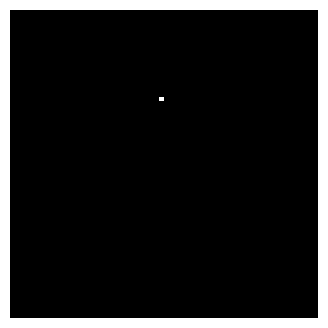

In [72]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from skimage.transform import hough_line, hough_line_peaks
import os
import requests
from google.colab.patches import cv2_imshow

url = "https://raw.githubusercontent.com/vision-agh/poc_sw/master/11_Hough/"

fileNames = ["dom.png", "kwadraty.png", "lab112.png"]
for fileName in fileNames:
    if not os.path.exists(fileName):
        r = requests.get(url + fileName, allow_redirects=True)
        open(fileName, "wb").write(r.content)

im = np.zeros((64, 64), dtype=np.uint8)

im[18, 31] = 1

fig, ax = plt.subplots()
fig.set_size_inches(4, 4)
ax.imshow(im, "gray")
ax.axis("off")

3. Wykonaj transformację Hougha obazu im. Wykorzystaj funkcję *hough_line* z modułu _skimage.transform_. Funkcja zwraca: macierz H (przestrzeń Hougha) oraz dwa wektory theta i rho dla kolejnych

In [73]:
h, theta, rho = hough_line(im)

4. Wyświetl przestrzeń Hougha za pomocą funkcji _plt.imshow_ (można też wykorzystać poniższą funkcję *show_hough*). Jak "wygląda" pojedynczy punkt w przestrzeni Hougha?

In [74]:
def show_hough(h, image):
    # Generating figure 1
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    ax = axes.ravel()

    ax[0].imshow(image, "gray")
    ax[0].set_title("Input image")
    ax[0].set_axis_off()

    ax[1].imshow(h, "gray")
    ax[1].set_title("Hough transform")
    ax[1].set_xlabel("Angles (degrees)")
    ax[1].set_ylabel("Distance (pixels)")
    ax[1].axis("image")

    plt.tight_layout()
    plt.show()

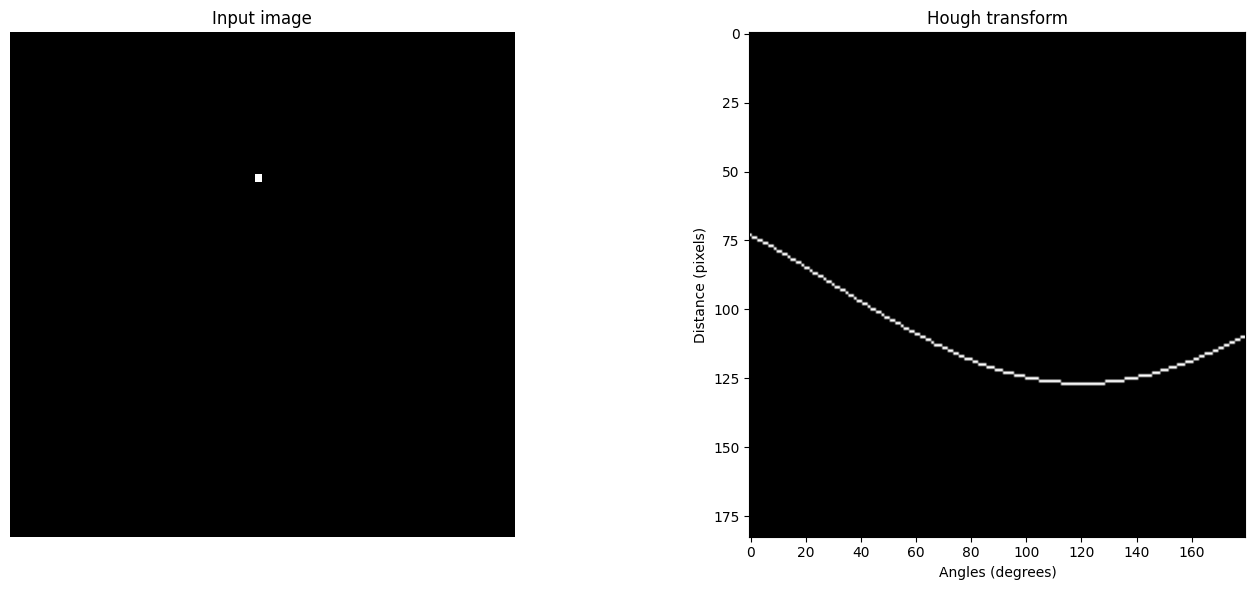

In [75]:
show_hough(h, im)

5. Powtórz punkty 1-4, ale tym razem klinkij dwa punkty. Jak zmienia się przestrzeń Hougha?


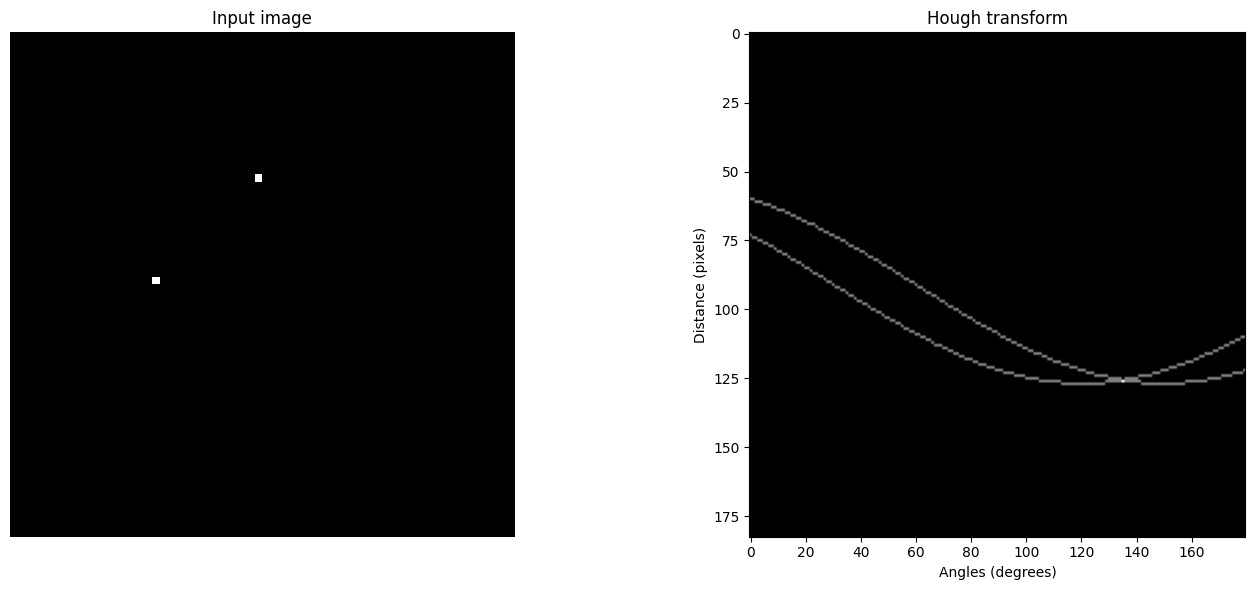

In [76]:
im[18, 31] = 1
im[31, 18] = 1
h, theta, rho = hough_line(im)
show_hough(h, im)

6. Powtórz punkty 1-4, ale tym razem kliknij kilka punktów starając się aby były współliniowe. Zaobserwuj zmiany w przestrzeni Hougha

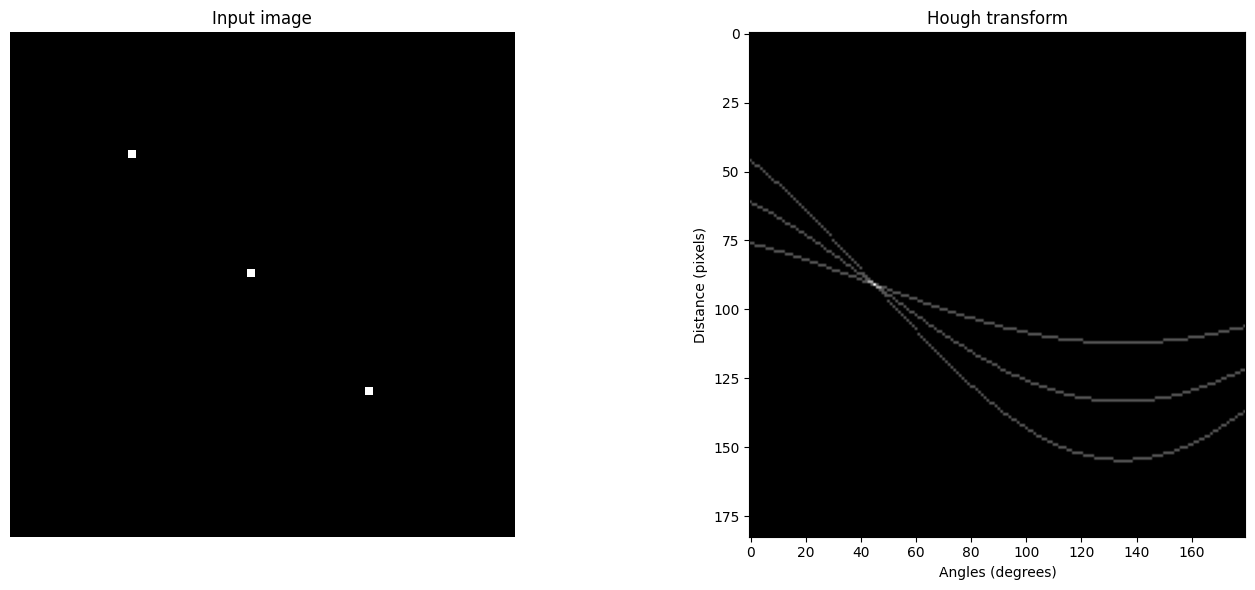

In [77]:
im = np.zeros((64, 64), dtype=np.uint8)
im[15, 15] = 1
im[30, 30] = 1
im[45, 45] = 1
h, theta, rho = hough_line(im)
show_hough(h, im)

7. Poeksperymentuj z różnymi układami punktów

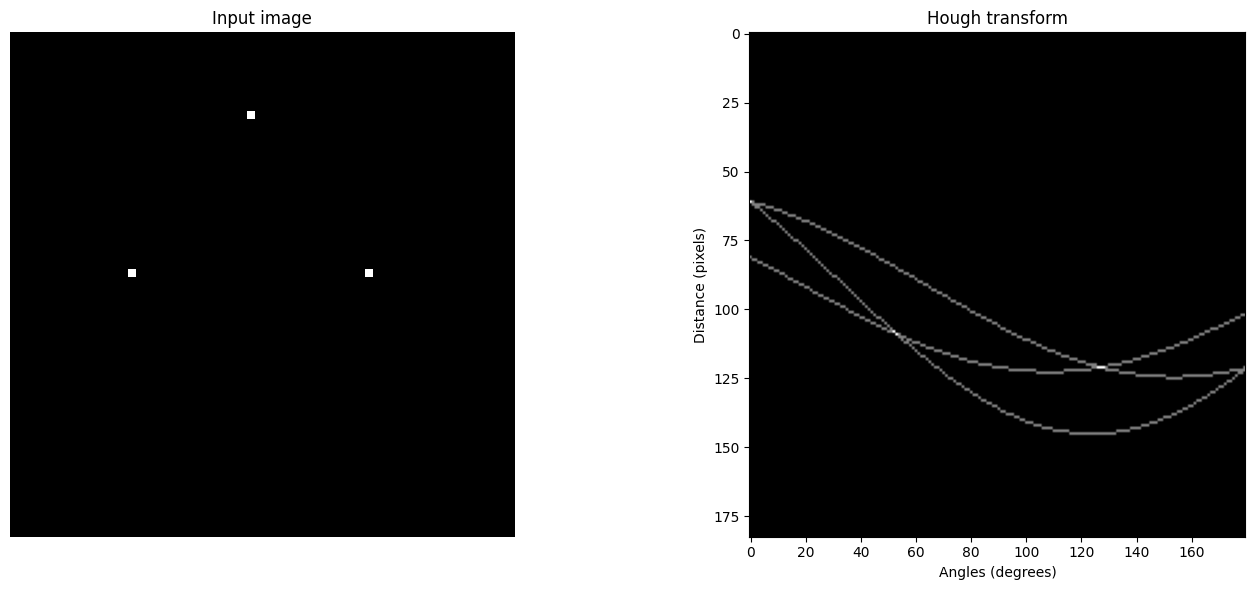

In [78]:
im = np.zeros((64, 64), dtype=np.uint8)
im[10, 30] = 1
im[30, 15] = 1
im[30, 45] = 1
h, theta, rho = hough_line(im)
show_hough(h, im)

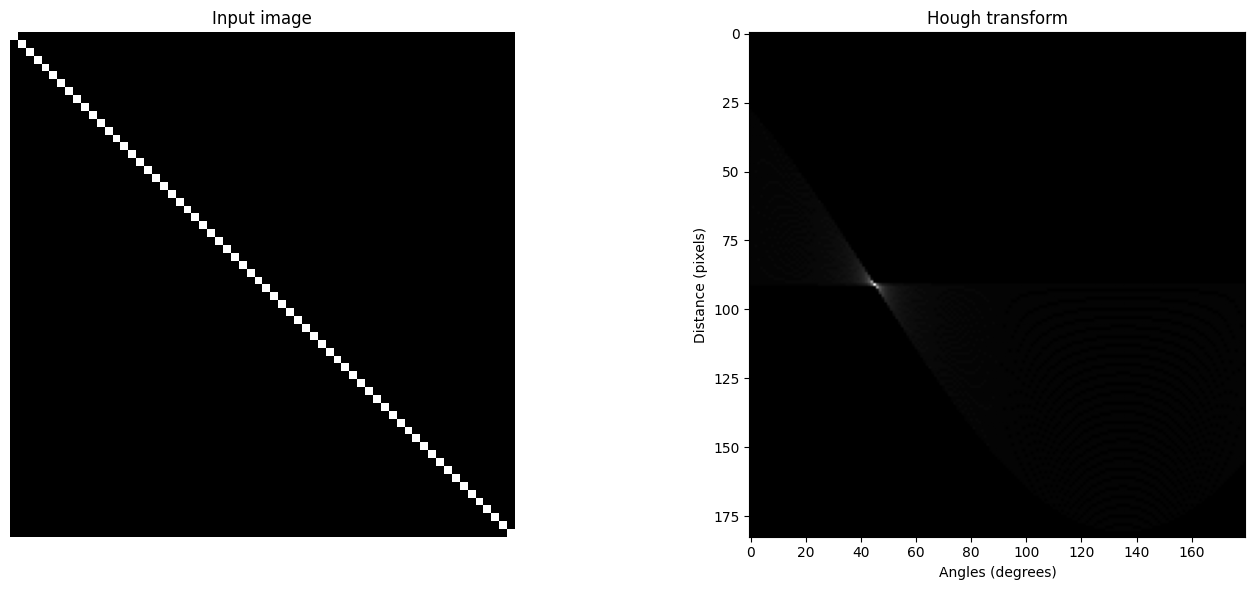

In [79]:
im = np.zeros((64, 64), dtype=np.uint8)
for i in range(64):
    im[i, i] = 1

h, theta, rho = hough_line(im)
show_hough(h, im)

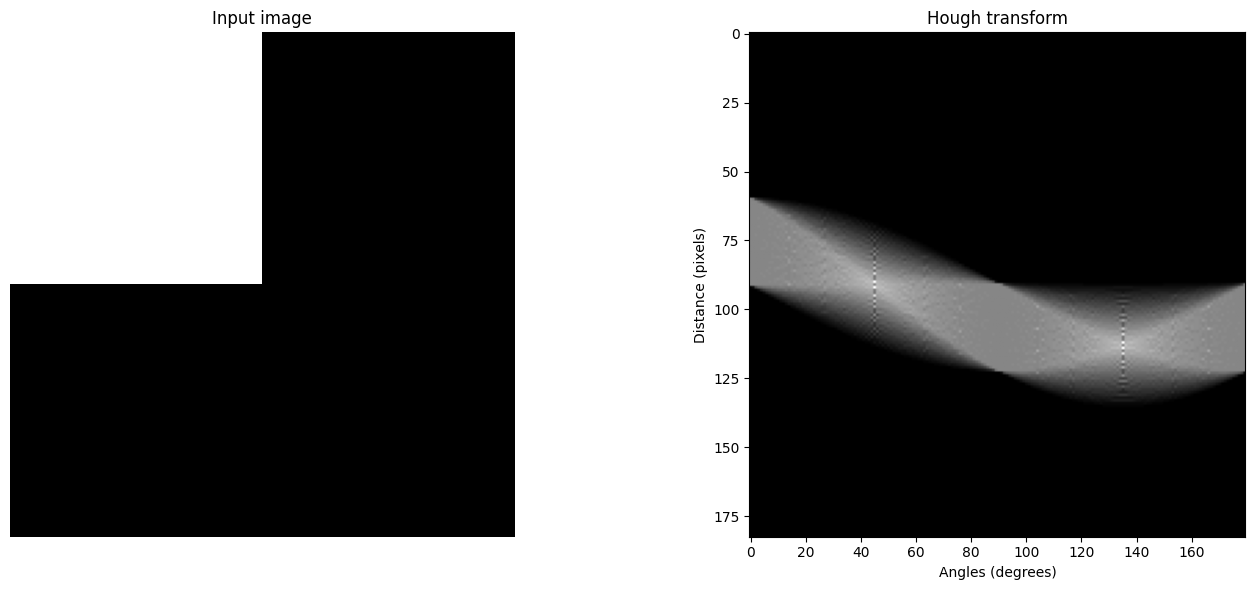

In [80]:
im = np.zeros((64, 64), dtype=np.uint8)
for i in range(32):
    for j in range(32):
        im[i, j] = 1

h, theta, rho = hough_line(im)
show_hough(h, im)

### Transformata Hougha dla pojedynczego obiektu

W tym podpunkcie pokazane zostanie praktycznie wykorzystanie transformaty Hougha - do detekcji prostych na sztucznym rysunku.

   1. Wczytaj obraz "kwadraty.png". Wyświetl go.

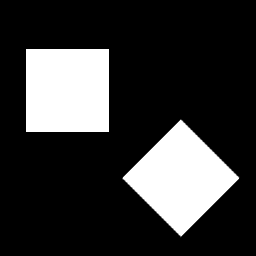

In [81]:
kwadraty = cv2.imread("kwadraty.png", cv2.IMREAD_GRAYSCALE)
cv2_imshow(kwadraty)

2. Wykonaj detekcję krawędzi jedną z metod gradientowych. Ważne aby obraz krawędzi był jak najlepszej jakości - co oznacza cienkie (nawet niekoniecznie ciągłe) krawędzie - dla tego przypadku nie powinno być trudne do uzyskania. Wyświetl obraz po detekcji krawędzi.
   

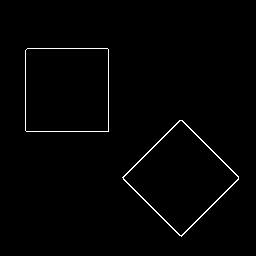

In [82]:
edges = cv2.Canny(kwadraty, threshold1=100, threshold2=200)
cv2_imshow(edges)

3. Wykonaj transformatę Hougha obrazu krawędziowego. Wykorzystaj funkcję *hough\_line*.
4. Wyświetl macierz H. Czy widoczna jest taka liczba maksimów jakiej się spodziewamy?

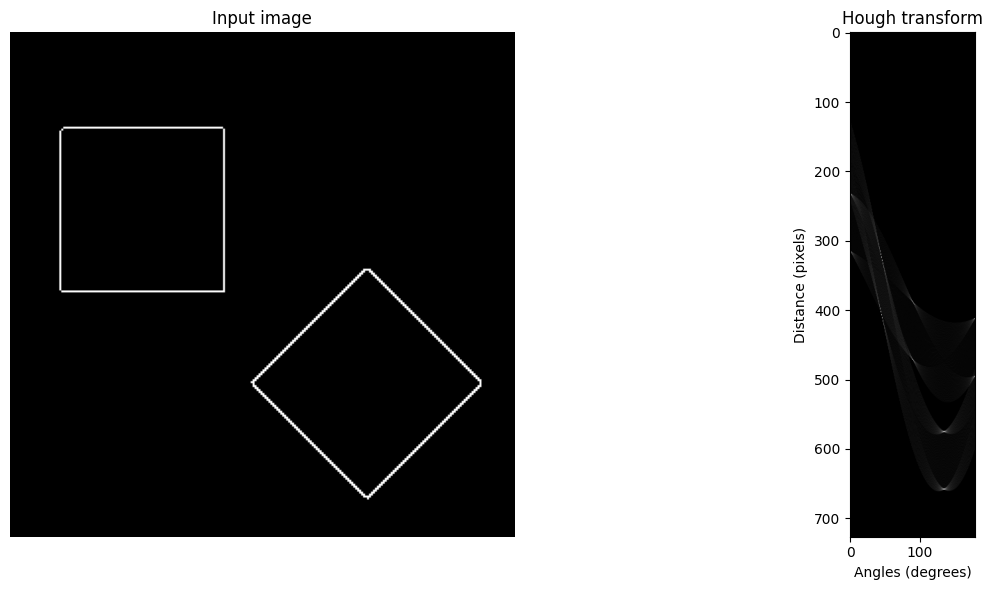

In [83]:
h, theta, rho = hough_line(edges)
show_hough(h, edges)

 5. W module skimage.transform dostępna jest funkcja do automatycznej analizy przestrzeni Hougha - wyszukiwania maksimów - *hough\_line\_peaks*. Jako parametry przyjmuje ona wyniki funkcji *hough\_line* (macierz H, theta i rho). Dodatkowo można podać próg powyżej którego punkt uznawany jest za maksimum (_threshold_ - domyslnie jest to połowa maksimum w przestrzeni H) oraz liczbę poszukiwanych maksimów (*num_peaks*). Funkcja zwraca współrzędne maksimów. Wykorzystaj funkcję *hough\_line\_peaks* do znalezienia maksimów odpowiadających krawędziom kwadratów.

 6. Wyświetl macierz H używając konstrukcji:

In [84]:
h_peaks, m_theta, m_rho = hough_line_peaks(h, theta, rho, num_peaks=8)

Taki zapis pozwoli na dołożenie annotacji (okręgów) w miejscach znalezionych maksimów. Wyrysowanie okręgu w punkcie x, y (o rozmiarze 10, w czerwonym kolorze, bez wypełnienia środka) realizuje wywołanie:

**circle = plt.Circle((x, y), 10, color='r', fill=False)**

natomiast dołożenie takiego okręgu do obrazu to:

**ax.add_patch(circle)**

Zaznacz maksima na obrazie wykorzystując rezultat funkcji *hough\_line\_peaks* biorąc pod uwagę, że zwraca ona kąty w radianach z przedziału od -pi/2 do pi/2, a rho z przedziału od -r/2 do r/2 gdzie r to pionowy rozmiar przestrzeni Hougha.

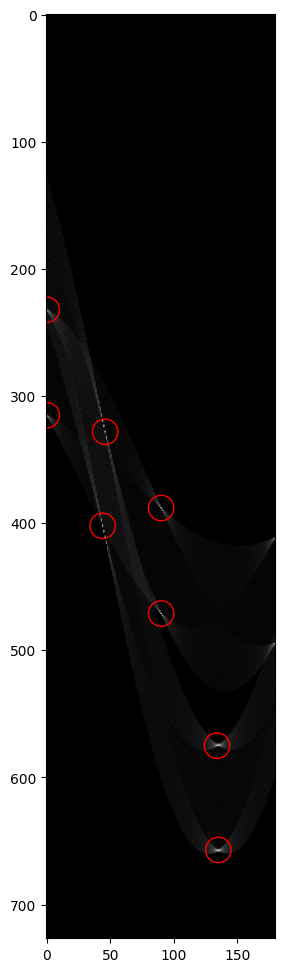

In [85]:
fig, ax = plt.subplots(1, figsize=(10, 12))
ax.set_aspect("equal")

ax.imshow(h, "gray")

for t, r in zip(m_theta, m_rho):
    t = (t + np.pi / 2) * (180 / np.pi)
    r = r + h.shape[0] // 2

    circle = plt.Circle((t, r), 10, color="r", fill=False)
    ax.add_patch(circle)

plt.show()

7. Istnieje też możliwość przeprowadzenia transformacji Hougha z użyciem biblioteki OpenCV. W bibliotece znajdują się dwie wersje funkcji wyszukującej linie proste - 'klasyczna' - _HoughLines_ oraz probabilistyczna _HoughLinesP_. Zadna z nich nie zwraca przestrzeni Hougha. Wynikiem działania pierwszej jest lista parametrów prostych (krotki zawierające rho, theta). Druga zwraca krotki 4-ro elementowe ze współrzędnymi końców odcinków wykorzystanych do wylicznia parametrów (czyli znalezienia prostej).
8. Wyznacz linie obecne na obrazie za pomocą funkcji _HoughLines_. Wykryte linie wyrysuj na obrazie początkowym (UWAGA: wczytanym bez konwersji na graylevel). Do wyświetlania linii wykorzystaj przykładowy kod:

In [112]:
lines = cv2.HoughLines(edges, 1, np.pi / 180, 60)

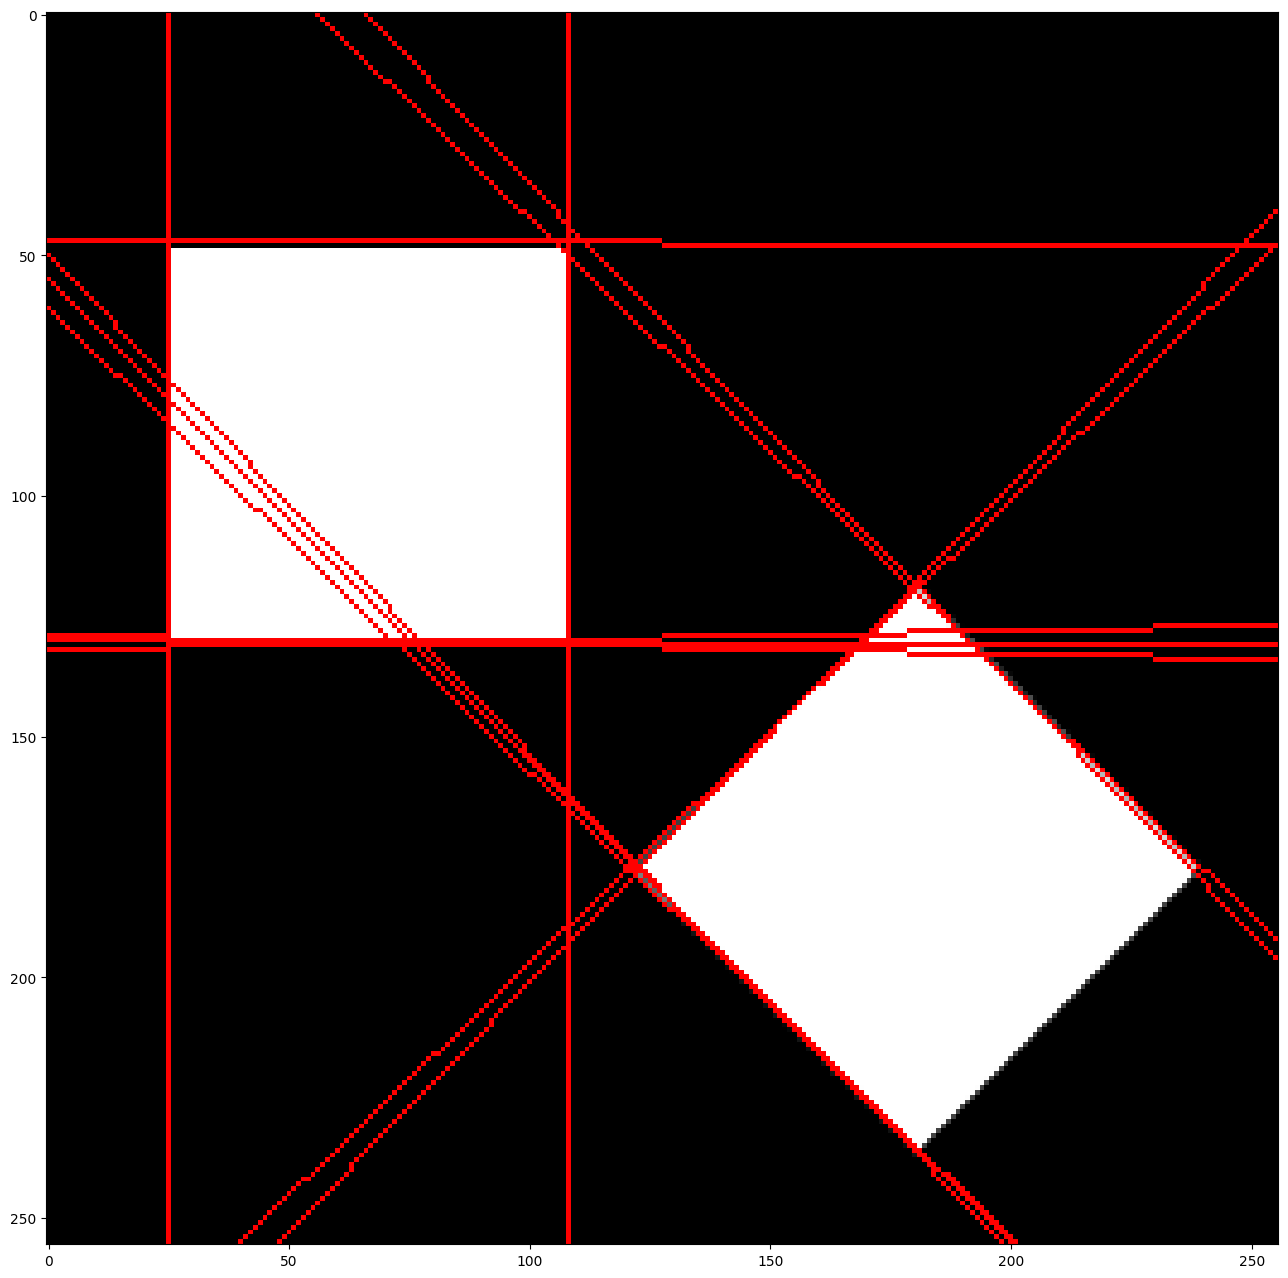

In [127]:
fig, ax = plt.subplots(1, figsize=(16, 16))
kwadraty_eg = cv2.cvtColor(kwadraty, cv2.COLOR_GRAY2RGB)

for line in lines:
    rho = line[0][0]
    theta = line[0][1]

    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    kwadraty_eg = cv2.line(kwadraty_eg, (x1, y1), (x2, y2), (255, 0, 0))

ax.imshow(kwadraty_eg)
plt.show()

9. Wyznacz odcinki obecne na obrazie za pomocą funkcji _HoughLinesP_. Wykryte odcinki wyrysuj na obrazie początkowym (UWAGA: wczytanym bez konwersji na graylevel).

In [131]:
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 40)

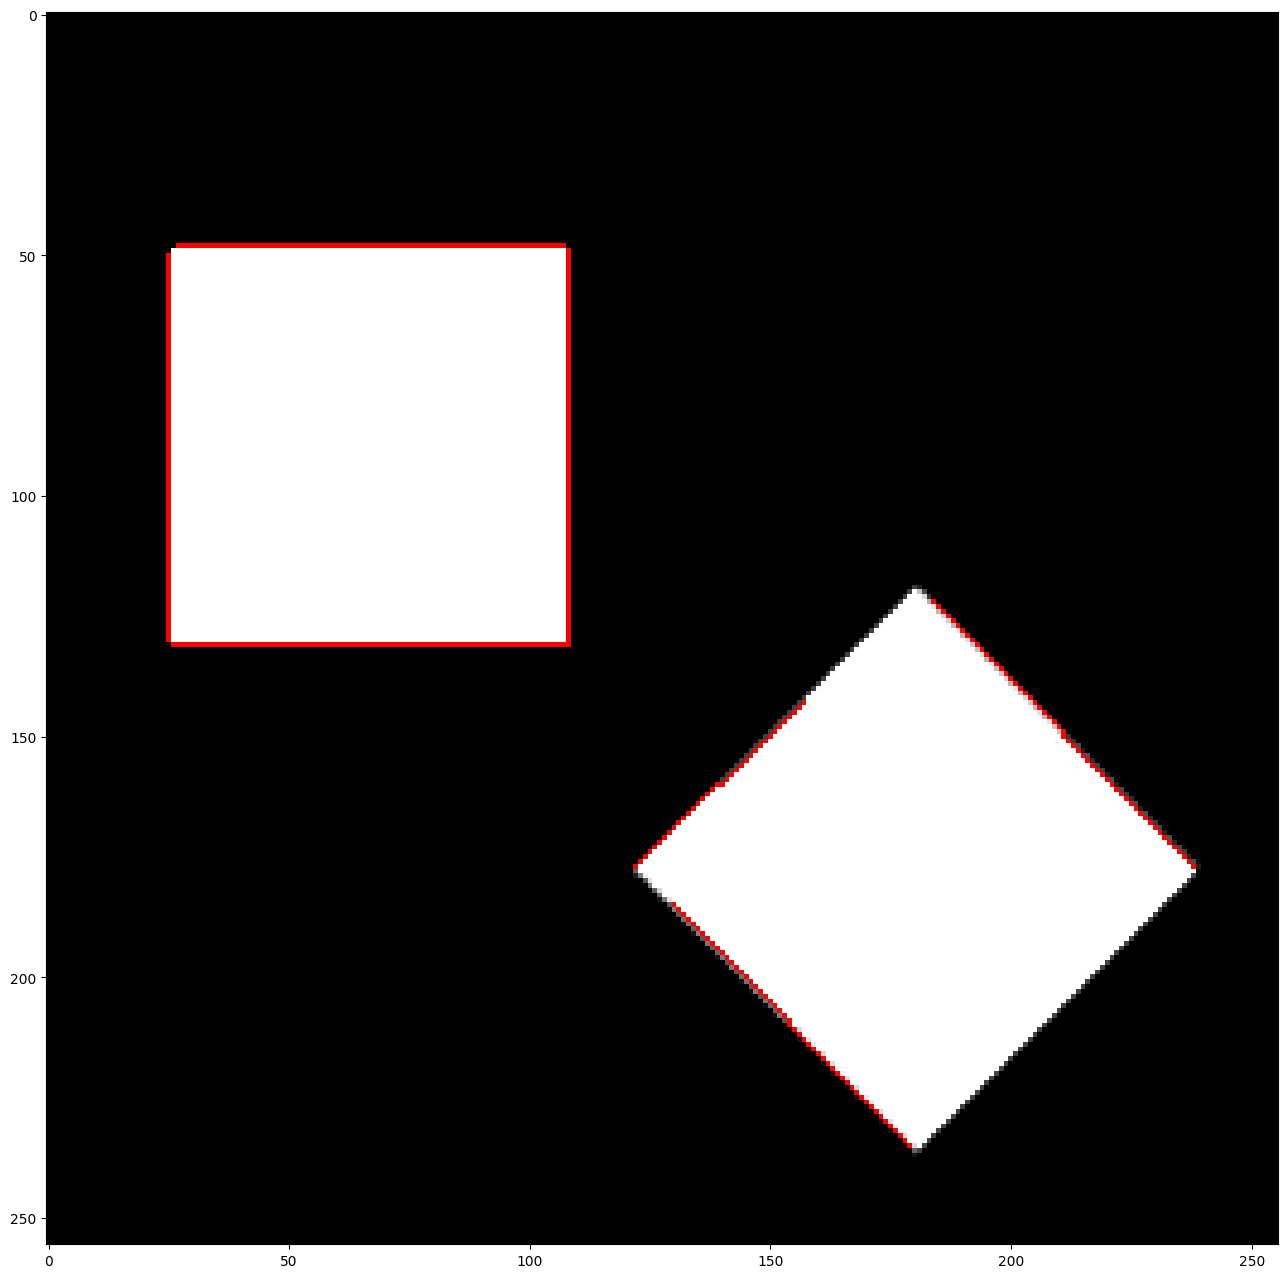

In [133]:
fig, ax = plt.subplots(1, figsize=(16, 16))
kwadraty_eg = cv2.cvtColor(kwadraty, cv2.COLOR_GRAY2RGB)

for line in lines:
    kwadraty_eg = cv2.line(kwadraty_eg, line[0][:2], line[0][2:], (255, 0, 0))

ax.imshow(kwadraty_eg)
plt.show()

### Transformata Hougha dla obrazu rzeczywistego.

Bazując na kodzie stworzonym w punkcie B wyszukamy linie na obrazie rzeczywistym.
   1. Wczytaj obraz "lab112.png". Wyświetl go.
   

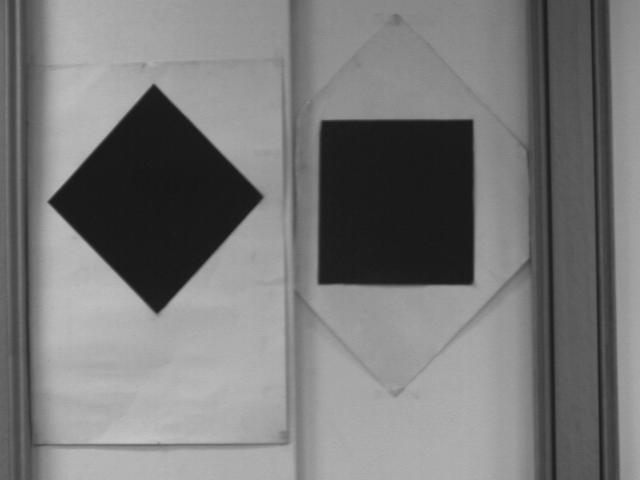

In [136]:
lab112 = cv2.imread("lab112.png", cv2.IMREAD_GRAYSCALE)
cv2_imshow(lab112)

2. Wykorzystując wszystkie poznane techniki przetwarzania obrazów (filtracja, przekształcenia morfologiczne, binaryzację, detekcję krawędzi) wyodrębnij krawędzie samych kwadratów - tak aby były jak najlepszej jakości (cienkie) - jednocześnie eliminując z obrazu zakłócenia.
  

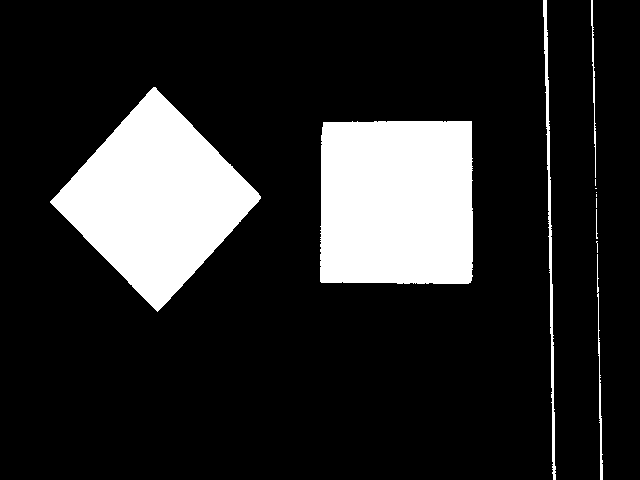

In [148]:
_, binary_lab112 = cv2.threshold(lab112, 40, 255, cv2.THRESH_BINARY_INV)
cv2_imshow(binary_lab112)

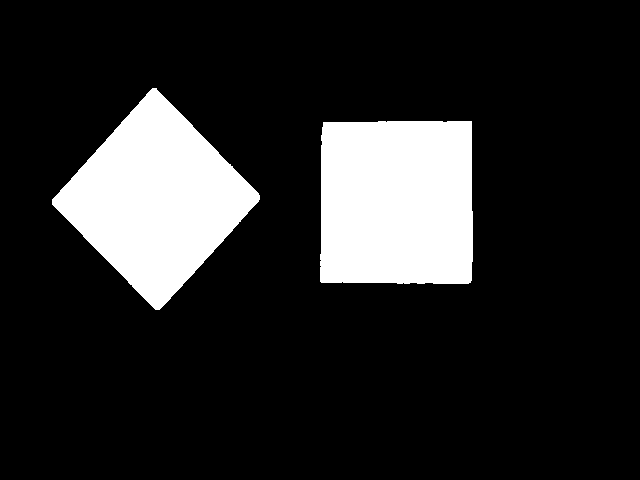

In [154]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
cleaned = cv2.morphologyEx(binary_lab112, cv2.MORPH_OPEN, kernel, iterations=2)
cv2_imshow(cleaned)

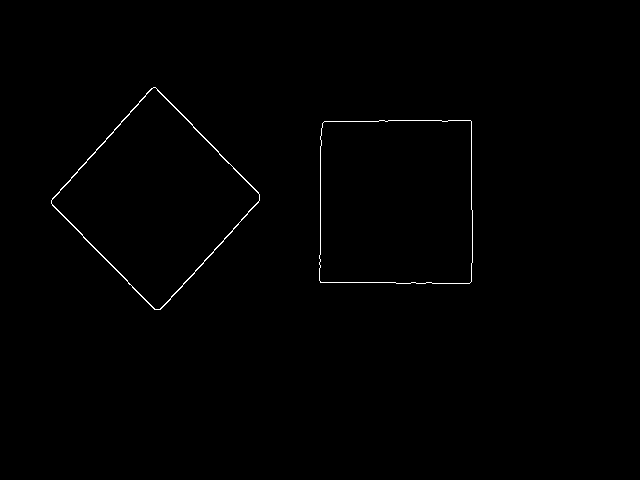

In [160]:
edges = cv2.Canny(cleaned, threshold1=100, threshold2=200)
cv2_imshow(edges)

3. Wykorzystaj funkcje *hough_line* i *hough_line_peaks* do detekcji linii na obrazie, a następnie np. wykorzystując kod z punktu 8 poprzedniego ustępu wyrysuj na oryginalnym obrazie znalezione linie.

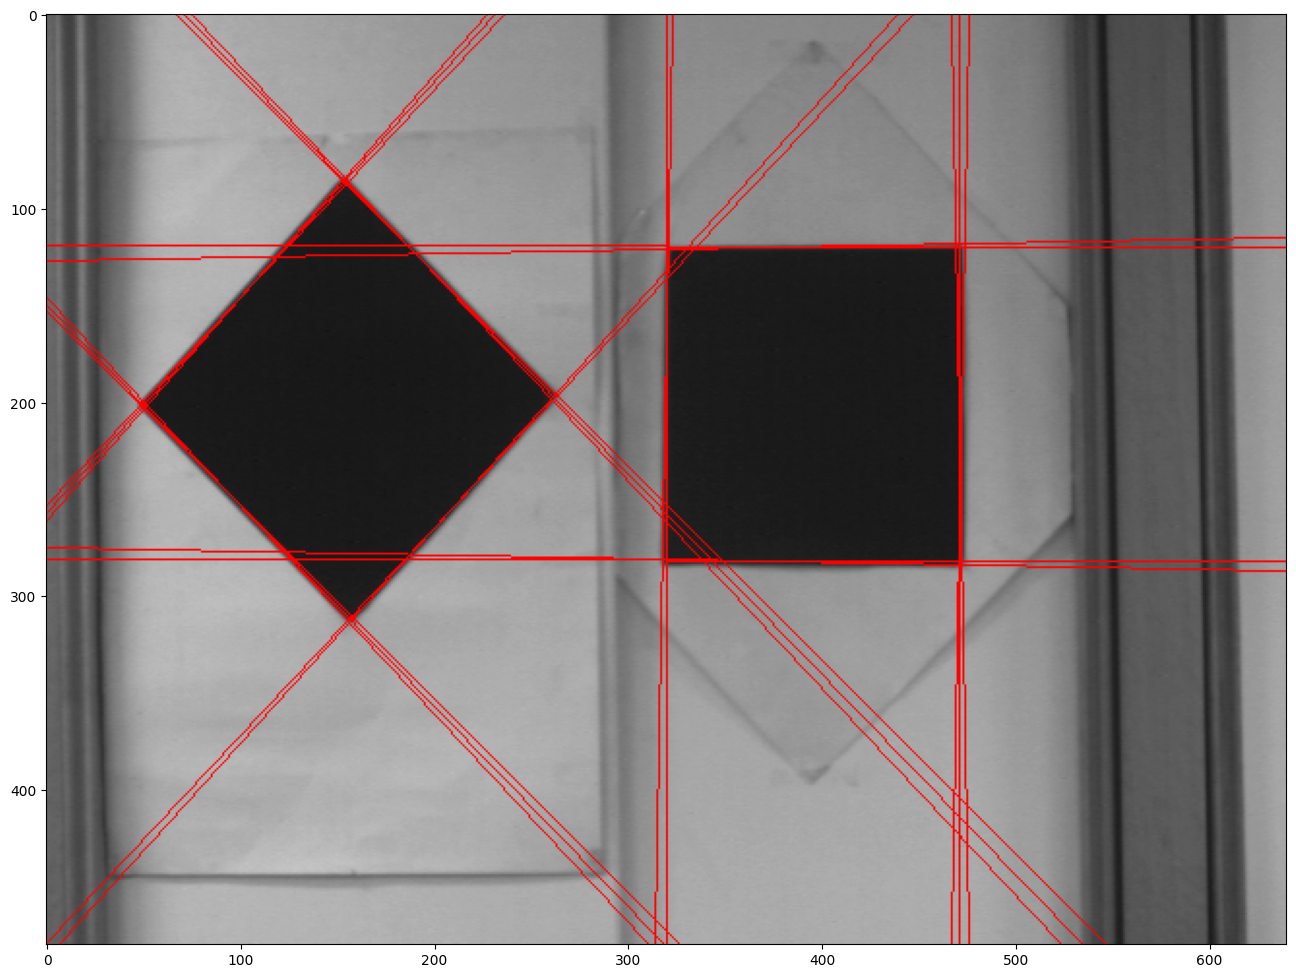

In [161]:
lines = cv2.HoughLines(edges, 1, np.pi / 180, 60)
fig, ax = plt.subplots(1, figsize=(16, 16))
lab112_eg = cv2.cvtColor(lab112, cv2.COLOR_GRAY2RGB)

for line in lines:
    rho = line[0][0]
    theta = line[0][1]

    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    lab112_eg = cv2.line(lab112_eg, (x1, y1), (x2, y2), (255, 0, 0))

ax.imshow(lab112_eg)
plt.show()

4. Wczytaj obraz "dom.png". Wypróbuj działanie transformacji Hougha na tym obrazie z wykorzystaniem funkcji _cv2.HoughLinesP_  (oczywiście po odpowiednich przekształceniach). Postaraj się tak przygotować obraz z krawędziami i dobrać parametry aby wyrysować na oryginalnym obrazie odcinki obejmujące zarysy domu. Weź pod uwage dodatkowe parametry funkcji, takie jak:   minLineLength, maxLineGap.

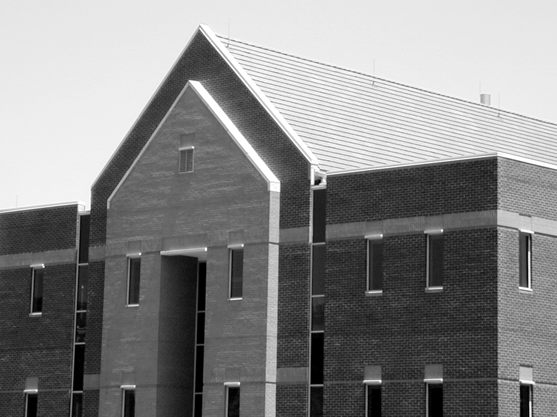

In [169]:
house = cv2.imread("dom.png", cv2.IMREAD_GRAYSCALE)
cv2_imshow(house)

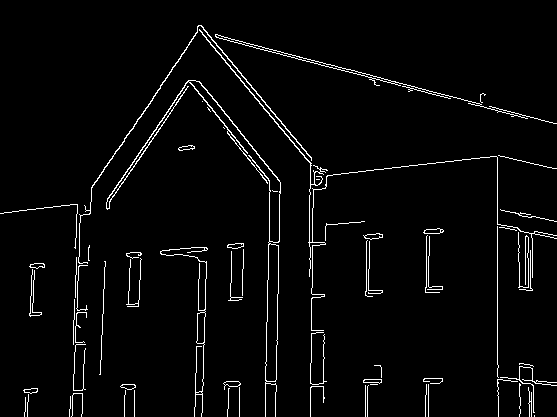

In [174]:
house_blur = cv2.GaussianBlur(house, (3, 3), 0)
edges = cv2.Canny(house_blur, 100, 200, None, 3, 1)
cv2_imshow(edges)

In [175]:
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 40)

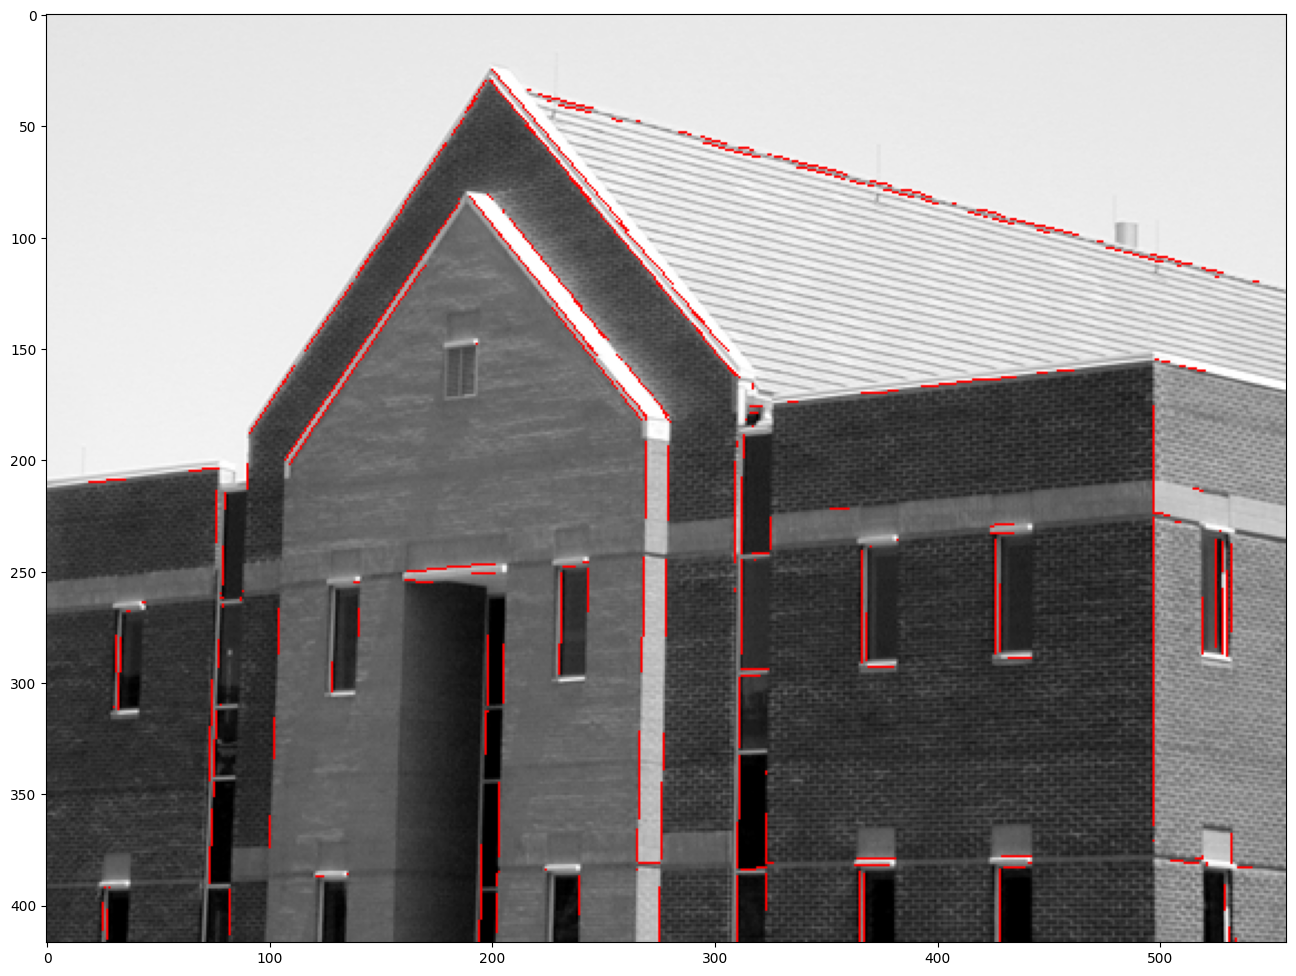

In [177]:
fig, ax = plt.subplots(1, figsize=(16, 16))
house_eg = cv2.cvtColor(house, cv2.COLOR_GRAY2RGB)

for line in lines:
    house_eg = cv2.line(house_eg, line[0][:2], line[0][2:], (255, 0, 0))

ax.imshow(house_eg)
plt.show()